In [1]:
!date

Fri Mar  6 10:50:06 AM EST 2026


In [2]:
pwd

'/projects/sccn/andromeda1/aglinska/deepcor-fmri-toolbox/tests'

In [3]:
# Cell Tagged parameters
import os
from pathlib import Path

bids_path = '../Data/fMRI-Data/studyforrest-fmriprep/'

subs = [sub for sub in os.listdir(os.path.join(bids_path)) if sub.startswith('sub-')]
subs.sort()

session = 'ses-localizer'
task = 'objectcategories'
space = 'MNI152NLin2009cAsym'

s = 0
r = 1
analysis_name = 'test'

In [4]:
sub_id = subs[s]
run = str(r)

print(sub_id)
print(run)
print(analysis_name)

sub-01
1
test


In [5]:
# Construct paths
base = os.path.join(bids_path,sub_id,session)

# EPI
epi_path = os.path.join(base,'func',f'{sub_id}_{session}_task-{task}_run-{run}_bold_space-{space}_preproc.nii.gz')

# Confounds
confounds_path = os.path.join(base,'func',f'{sub_id}_{session}_task-{task}_run-{run}_bold_confounds.tsv')

gm_mask_path = os.path.join(bids_path,'mask_roi.nii')
cf_mask_path = os.path.join(bids_path,'mask_roni.nii')

assert os.path.exists(epi_path), 'epi_path does not exist'
assert os.path.exists(confounds_path), 'confounds_path does not exist'
assert os.path.exists(gm_mask_path), 'gm_mask_path does not exist'
assert os.path.exists(cf_mask_path), 'cf_mask_path does not exist'

os.makedirs(os.path.join('../Data/DeepCor-Outputs',analysis_name), exist_ok=True)
output_dir = os.path.join('../Data/DeepCor-Outputs',analysis_name,f'DeepCor-Forrest-{sub_id}-{task}-{run}-cvae_v1')

print("EPI:", epi_path)
print("Confounds:", confounds_path)
print("output_dir:", output_dir)

EPI: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-1_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
Confounds: ../Data/fMRI-Data/studyforrest-fmriprep/sub-01/ses-localizer/func/sub-01_ses-localizer_task-objectcategories_run-1_bold_confounds.tsv
output_dir: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-01-objectcategories-1-cvae_v1


In [6]:
import torch
from deepcor import DeepCorDenoiser

# ---------------------------
# Run DeepCor (simplified API)
# ---------------------------

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# model_version:
# - "v1": original CVAE
# - "v2": current CVAE (default / latest)
# - "latest": alias for the current recommended model

denoiser = DeepCorDenoiser(
    model_version="v1",
    device=device, # you can tweak these, but defaults are fine for a first run
    n_epochs=5,           # keep small for a quick sanity run; increase for real denoising
    n_repetitions=2,      # keep small for a quick sanity run; increase for real denoising
    batch_size=1024,
    latent_dims=(8, 8),   # for v1 only the first value is used
    verbose=True,
)

output_path = denoiser.fit_denoise(
    epi_path=str(epi_path),
    gm_mask_path=str(gm_mask_path),
    cf_mask_path=str(cf_mask_path),
    confounds_path=str(confounds_path),
    output_dir=str(output_dir),
    verbose=True,
)

print("\nDone. Denoised file:", output_path)

Using device: cuda:0
device is cuda:0
Loading data...
Preparing training data...
obs_list.shape: (41116, 156)
noi_list.shape: (9092, 156)
upsampling noi_list_coords
obs_list.shape: (41116, 156)
noi_list.shape: (41116, 156)


Training repetition 1:   0%|                                                                       | 0/2 [00:00<?, ?it/s]

Error in epoch 0: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [1024, 1, 1, 156]


Traceback (most recent call last):
  File "/projects/sccn/andromeda1/aglinska/deepcor-fmri-toolbox/deepcor/training/trainer.py", line 145, in fit
    avg_loss = self.train_epoch(dataloader)
  File "/projects/sccn/andromeda1/aglinska/deepcor-fmri-toolbox/deepcor/training/trainer.py", line 89, in train_epoch
    outputs = self.model.forward_tg(inputs_gm)
  File "/projects/sccn/andromeda1/aglinska/deepcor-fmri-toolbox/deepcor/models/cvae_v1.py", line 177, in forward_tg
    tg_mu_z, tg_log_var_z = self.encode_z(input)
  File "/projects/sccn/andromeda1/aglinska/deepcor-fmri-toolbox/deepcor/models/cvae_v1.py", line 143, in encode_z
    result = self.encoder_z(input)
  File "/home/aglinska/anaconda3/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1553, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/home/aglinska/anaconda3/lib/python3.8/site-packages/torch/nn/modules/module.py", line 1562, in _call_impl
    return forward_call(*args, **kwargs)
  File "

Error in repetition 0: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [512, 1, 1, 156]
Error in epoch 0: Expected 2D (unbatched) or 3D (batched) input to conv1d, but got input of size: [1024, 1, 1, 156]


...

100%|██████████| 2/2 [00:01<00:00,  1.08it/s]

100%|██████████| 2/2 [00:01<00:00,  1.06it/s]

signals averaged: 2


Saving comparison outputs...


Denoising complete! Output saved to: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/denoised_deepcor.nii.gz

Done. Denoised file: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/denoised_deepcor.nii.gz


In [ ]:
from deepcor.analysis import get_design_matrix, run_correlation_analysis_from_spec, run_contrast_analysis_from_spec

In [ ]:
#!cp -r ../../BC-ABCD-denoise/Data/StudyForrest/events ../Data/
events_path = f'../Data/study-forrest-events/{sub_id}_ses-localizer_task-objectcategories_run-{run}_events.tsv'
assert os.path.exists(events_path),'events_path does not exist'

import ants
epi = ants.image_read(epi_path)
X1 = get_design_matrix(epi,events_path)

In [ ]:
#!cp -r ../../BC-ABCD-denoise/Data/StudyForrest/ROIs/ ../Data/

correlation_analyses = []
contrast_analyses = []

correlation_analyses.append(
    {'corr_target' : X1['face'].values,
     'filename' : os.path.join(output_dir,'corr2face.nii.gz'),
     'plot' : True, 
     'ROI' : f'../Data/study-forrest-ROIs/rFFA_final_mask_{sub_id}_bin.nii.gz'})

correlation_analyses.append(
    {'corr_target' : X1[['house','scene']].values.mean(axis=1),
     'filename' : os.path.join(output_dir,'corr2place.nii.gz'),
     'plot' : True,
     'ROI' : f'../Data/study-forrest-ROIs/rPPA_final_mask_{sub_id}_bin.nii.gz'})

contrast_analyses.append(
    {'contrast_vec' : [-1,5,-1,-1,-1,-1,0,0,0,0],
     'design_matrix' : X1,
     'filename' : os.path.join(output_dir,'contrast_face.nii.gz'),
     'plot' : True, 
     'ROI' : f'../Data/study-forrest-ROIs/rFFA_final_mask_{sub_id}_bin.nii.gz'})

contrast_analyses.append(
    {'contrast_vec' : [-1,-1,2,-1,2,-1,0,0,0,0],
     'design_matrix' : X1,
     'filename' : os.path.join(output_dir,'contrast_place.nii.gz'),
     'plot' : True,
     'ROI' : f'../Data/study-forrest-ROIs/rPPA_final_mask_{sub_id}_bin.nii.gz'})

In [11]:
signals_averaged = ants.image_read(os.path.join(output_dir,'denoised_deepcor.nii.gz'))
compcor = ants.image_read(os.path.join(output_dir,'denoised_compcor.nii.gz'))
#epi = ants.image_read(os.path.join(output_dir,'denoised_deepcor.nii.gz'))
gm = ants.image_read(gm_mask_path)

saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/corr2face_preproc.nii.gz
saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/corr2face_compcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/corr2face_deepcor.nii.gz


saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/corr2place_preproc.nii.gz
saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/corr2place_compcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/corr2place_deepcor.nii.gz


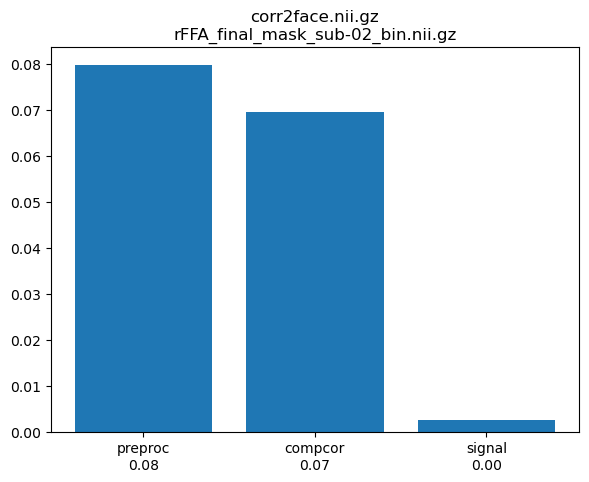

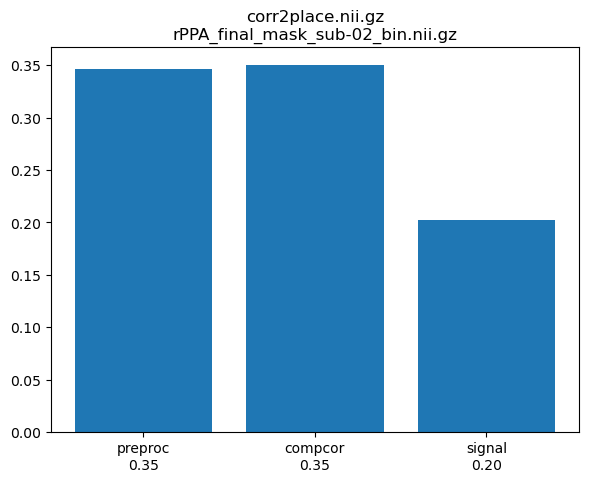

In [12]:
run_correlation_analysis_from_spec(correlation_analyses[0], epi, compcor, signals_averaged,gm)
run_correlation_analysis_from_spec(correlation_analyses[1], epi, compcor, signals_averaged,gm)

saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/contrast_face_preproc.nii.gz
saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/contrast_face_compcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/contrast_face_deepcor.nii.gz


saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/contrast_place_preproc.nii.gz
saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/contrast_place_compcor.nii.gz
saved as: ../Data/DeepCor-Outputs/test/DeepCor-Forrest-sub-02-objectcategories-4-cvae_v1/contrast_place_deepcor.nii.gz


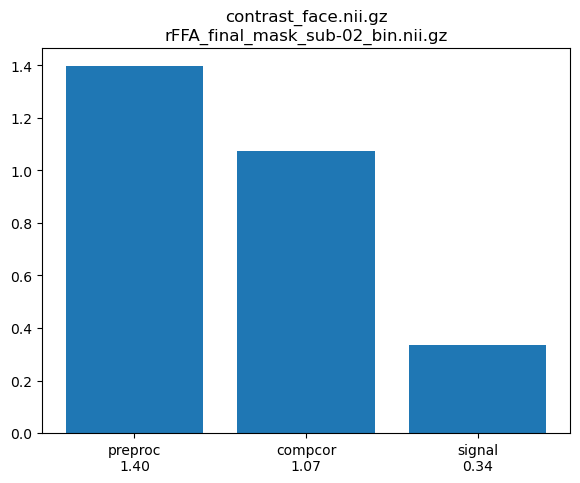

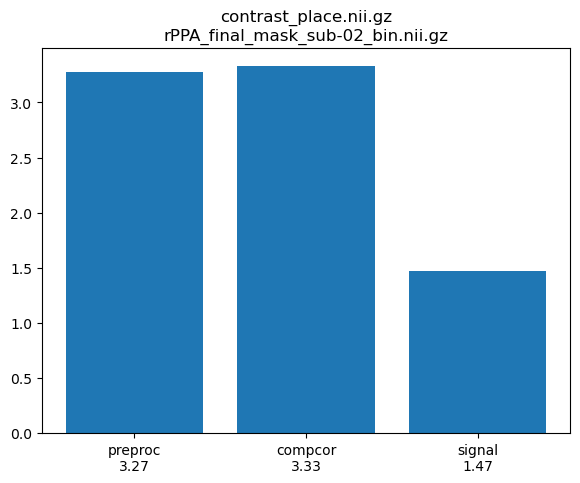

In [13]:
run_contrast_analysis_from_spec(contrast_analyses[0], epi, compcor, signals_averaged,gm)
run_contrast_analysis_from_spec(contrast_analyses[1], epi, compcor, signals_averaged,gm)